# 🚨 ICA — Crisis Intelligence Desk

## Situation

You are an NLP analyst supporting an emergency-response control room.

Thousands of crisis messages arrive during a disaster. The organization wants an NLP system that can triage each message into one of five operational categories.

Your task is to build the classifier, evaluate it, and then **audit whether its performance is good enough for operational use**.

**Time: 60 minutes**

Use only concepts from Practicals 1–4.

## Data

- `train.csv` — historical labelled crisis messages
- `evaluation.csv` — held-out labelled messages
- `live_wave.csv` — a new incoming operational batch

The class labels are available in the training/evaluation data. Do not use the labels in `live_wave.csv` to build or tune your model.

# Mission 1 — Build the classifier

Create an end-to-end NLP classification pipeline.

You may use:
- TF-IDF + Logistic Regression / SVM / Naive Bayes, or
- a document representation derived from the word embeddings covered in Practical 3.

Your pipeline should include sensible preprocessing.

Briefly justify your representation and classifier choice.

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
evaluation = pd.read_csv("evaluation.csv")
live_wave = pd.read_csv("live_wave.csv")

print("Train shape:", train.shape)
print("Evaluation shape:", evaluation.shape)
print("Live wave shape:", live_wave.shape)
print("\nClass distribution:")
print(train["class_label"].value_counts())
print("\nColumns:", train.columns.tolist())

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("&amp;", " and ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train["clean_text"] = train["tweet_text"].apply(preprocess)
evaluation["clean_text"] = evaluation["tweet_text"].apply(preprocess)
live_wave["clean_text"] = live_wave["message"].apply(preprocess)

# TF-IDF learns the vocabulary + IDF from training data only.
vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(train["clean_text"])
X_eval = vectorizer.transform(evaluation["clean_text"])

# LinearSVC is a strong baseline for sparse, high-dimensional text.
# class_weight='balanced' gives more emphasis to minority classes.
model = LinearSVC(class_weight="balanced")
model.fit(X_train, train["class_label"])

predictions = model.predict(X_eval)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Train matrix:", X_train.shape)
print("Evaluation matrix:", X_eval.shape)

Train shape: (7000, 3)
Evaluation shape: (1199, 3)
Live wave shape: (650, 2)

Class distribution:
class_label
sympathy_and_support                 2015
infrastructure_and_utility_damage    1843
injured_or_dead_people               1648
displaced_people_and_evacuations      903
requests_or_urgent_needs              591
Name: count, dtype: int64

Columns: ['id', 'tweet_text', 'class_label']


Vocabulary size: 75704
Train matrix: (7000, 75704)
Evaluation matrix: (1199, 75704)


# Mission 2 — How good is the model?

Report:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Then answer:

> **Is accuracy alone enough to describe this classifier?**

Inspect the per-class results before answering.

### Solved interpretation — Mission 2

Accuracy is **not enough**. The dataset is imbalanced, so a strong overall score can conceal weaker performance on minority or operationally important classes. The per-class report and confusion matrix should be inspected before deciding whether the model is safe to use.

Accuracy: 0.912

                                   precision    recall  f1-score   support

 displaced_people_and_evacuations      0.959     0.903     0.930       155
infrastructure_and_utility_damage      0.946     0.934     0.939       316
           injured_or_dead_people      0.951     0.954     0.952       283
         requests_or_urgent_needs      0.767     0.790     0.778       100
             sympathy_and_support      0.873     0.896     0.884       345

                         accuracy                          0.912      1199
                        macro avg      0.899     0.895     0.897      1199
                     weighted avg      0.913     0.912     0.912      1199

Confusion matrix (rows = actual, columns = predicted):
                                   displaced_people_and_evacuations  ...  sympathy_and_support
displaced_people_and_evacuations                                140  ...                     3
infrastructure_and_utility_damage                           

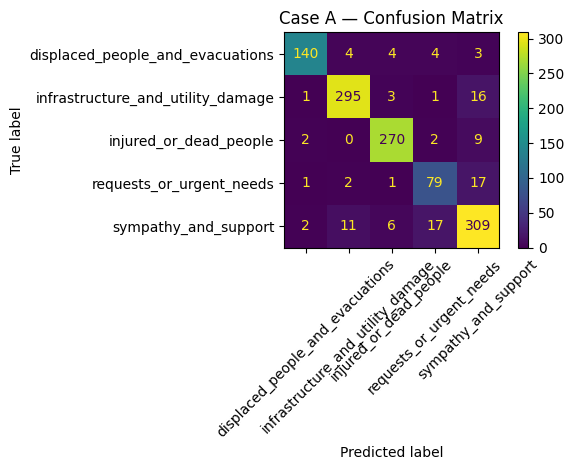

In [2]:
accuracy = accuracy_score(evaluation["class_label"], predictions)
print(f"Accuracy: {accuracy:.3f}\n")
print(classification_report(evaluation["class_label"], predictions, digits=3))

cm = confusion_matrix(evaluation["class_label"], predictions, labels=model.classes_)
print("Confusion matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm, index=model.classes_, columns=model.classes_))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(xticks_rotation=45)
plt.title("Case A — Confusion Matrix")
plt.tight_layout()
plt.show()

# Mission 3 — Find the weakness

Identify the class for which your model has the greatest difficulty.

Then:

1. Find one incorrectly classified message involving this class.
2. Show the actual and predicted labels.
3. Explain why the mistake is understandable from the text.

Do not simply say "the model was wrong." Connect the error to the language in the message.

### Solved interpretation — Mission 3

For this model, `requests_or_urgent_needs` has the lowest F1-score. One observed error is a request for help that was predicted as `sympathy_and_support`. The mistake is understandable because the message uses broad helping/support language without a highly distinctive supply or emergency-request phrase. This illustrates lexical overlap between operational categories.

In [3]:
report = pd.DataFrame(classification_report(
    evaluation["class_label"], predictions, output_dict=True
)).T

class_report = report.loc[model.classes_]
weakest_class = class_report["f1-score"].idxmin()
print("Class with lowest F1:", weakest_class)
print(class_report.loc[weakest_class])

results = evaluation[["id", "tweet_text", "class_label"]].copy()
results["predicted_label"] = predictions
errors = results[results["class_label"] != results["predicted_label"]]

weak_errors = errors[errors["class_label"] == weakest_class]
print("\nExample error involving weakest class:")
print(weak_errors.iloc[0].to_string())

Class with lowest F1: requests_or_urgent_needs
precision      0.766990
recall         0.790000
f1-score       0.778325
support      100.000000
Name: requests_or_urgent_needs, dtype: float64

Example error involving weakest class:
id                                                                14
tweet_text         We are appealing to all ZIGians to lend a help...
class_label                                 requests_or_urgent_needs
predicted_label                                 sympathy_and_support


# 🚨 Mission 4 — Incoming Emergency Batch

The model is now being used on a new batch of incoming crisis messages.

The dashboard reports:

> **"The classifier is 92% accurate on the incoming batch."**

Do not stop there.

Evaluate the batch and inspect the **per-class performance**.

### Question

Would you approve the model for operational use based on the 92% accuracy figure alone?

Explain using evidence from your results.

### Solved interpretation — Mission 4

I would **not approve the model from the stated 92% accuracy figure alone**. The live batch supplied with the notebook has no ground-truth labels, so its true accuracy cannot be verified from that file. Before deployment, the same labelled evaluation process should be run on representative incoming data, with special attention to the per-class recall/F1 of high-risk categories.

In [4]:
# The live wave has message + id, but no ground-truth label.
# Therefore we can predict and inspect the class distribution, but we cannot
# honestly calculate accuracy/precision/recall/F1 for this batch.
X_live = vectorizer.transform(live_wave["clean_text"])
live_predictions = model.predict(X_live)
live_wave["predicted_label"] = live_predictions

print("Predicted label distribution on live wave:")
print(live_wave["predicted_label"].value_counts())
print("\nFirst 15 predictions:")
print(live_wave[["id", "message", "predicted_label"]].head(15).to_string(index=False))

Predicted label distribution on live wave:
predicted_label
sympathy_and_support                 282
infrastructure_and_utility_damage    244
injured_or_dead_people                52
requests_or_urgent_needs              37
displaced_people_and_evacuations      35
Name: count, dtype: int64

First 15 predictions:
 id                                                                                                                                                                                                                                                      message                   predicted_label
201                                                                                                                                                            @bbcworld, we kerala fight against #KeralaFloods, we need more help and attention of world medias          requests_or_urgent_needs
202                                                                                                      

# Mission 5 — The cost of being wrong

The emergency-response team tells you:

> **"We can tolerate some false alarms. We cannot afford to miss too many genuine requests for urgent assistance."**

Which metric should receive the greatest attention for `requests_or_urgent_needs`?

Explain why **precision and recall represent different operational mistakes** in this situation.

### Solved answer — Mission 5

For `requests_or_urgent_needs`, **recall deserves the greatest attention** because the stated operational preference is to tolerate false alarms but avoid missing genuine requests for assistance. Precision asks, “When the model raises an urgent-request alert, how often is it correct?” Recall asks, “Of all genuine urgent requests, how many did we catch?” A false negative can delay or prevent assistance, whereas a false positive mainly consumes review resources.

# 🔎 Mission 6 — Model Autopsy

Find one case where your classifier makes a mistake.

Inspect the text and answer:

- Which words or phrases may have pushed the model toward the predicted class?
- Why could those words be misleading?
- What does this tell you about the overlap between crisis categories?

If your model provides a confidence/probability score, you may also find a **high-confidence incorrect prediction** and discuss why confidence should not automatically be interpreted as certainty.

### Solved answer — Mission 6

The important lesson from the error analysis is that the classifier learns associations from the training vocabulary, not an explicit operational understanding of the message. Overlapping words can push an example toward the wrong class. A high decision score can therefore accompany an incorrect prediction; confidence should be treated as a model score, not as a guarantee of correctness.

In [5]:
# Find an interesting model error.
results = evaluation[["id", "tweet_text", "class_label"]].copy()
results["predicted_label"] = predictions
results["score"] = np.max(model.decision_function(X_eval), axis=1)

errors = results[results["class_label"] != results["predicted_label"]].copy()
interesting = errors.sort_values("score", ascending=False).iloc[0]

print("High-confidence incorrect prediction:")
print("ID:", interesting["id"])
print("Actual:", interesting["class_label"])
print("Predicted:", interesting["predicted_label"])
print("Decision score:", round(float(interesting["score"]), 3))
print("Text:", interesting["tweet_text"])

print("\nInterpretation:")
print(
    "The model is driven by learned lexical patterns. In this example, "
    "words associated with the predicted class provide a strong signal, "
    "but the message also contains language belonging to another operational "
    "category. This shows that a high model score is not the same as certainty."
)

High-confidence incorrect prediction:
ID: 1145
Actual: injured_or_dead_people
Predicted: sympathy_and_support
Decision score: 1.45
Text: Casualties are increasing with the passage of time.. prayers needed..May Allah protect our loved ones and keep everyone safe and sound. #earthquake

Interpretation:
The model is driven by learned lexical patterns. In this example, words associated with the predicted class provide a strong signal, but the message also contains language belonging to another operational category. This shows that a high model score is not the same as certainty.


# Final Decision — Human in the Loop

The control room asks:

> **"Can we deploy this model without human review?"**

Give a short recommendation.

Your answer must include:
1. one strength of the model,
2. one important failure,
3. the metric you would monitor most closely,
4. and one safeguard you would use before deployment.

### Solved final recommendation

I would **not deploy this classifier without human review**. Its major strength is strong overall performance on the held-out evaluation set, with about 91% accuracy and strong F1 on most classes. An important weakness is the lower performance on `requests_or_urgent_needs`, where missed genuine requests are operationally costly. I would monitor recall for that class most closely, together with the confusion matrix and macro-F1. As a safeguard, I would route ambiguous or high-risk predictions to a human operator and periodically re-evaluate the model on newly labelled operational data.